In [1]:
from pathlib import Path

In [2]:
path = Path("./../dl/2/IMDB Dataset.csv")

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)

In [5]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df["label"] = df.sentiment.map({"negative":0, "positive":1})

In [8]:
df

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0
49997,I am a Catholic taught in parochial elementary...,negative,0
49998,I'm going to have to disagree with the previou...,negative,0


In [9]:
x = df.review

In [10]:
y = df.label

In [11]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: label, Length: 50000, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
x_train.shape

(40000,)

In [14]:
y_train.shape

(40000,)

In [15]:
MAX_TOKENS = 10000
SEQ_LEN = 200

In [16]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=SEQ_LEN
)

In [17]:
data_sc = tf.data.Dataset.from_tensor_slices(x_train).batch(256)

In [18]:
vectorizer.adapt(data_sc)

In [19]:
model = Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])                                  

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
x_train = x_train.astype('str').to_numpy()

In [22]:
y_train = y_train.to_numpy()

In [23]:
history = model.fit(
    x_train,
    y_train,
    epochs=7,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7154 - loss: 0.5599 - val_accuracy: 0.8298 - val_loss: 0.3911
Epoch 2/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8610 - loss: 0.3319 - val_accuracy: 0.8665 - val_loss: 0.3186
Epoch 3/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8905 - loss: 0.2711 - val_accuracy: 0.8692 - val_loss: 0.3150
Epoch 4/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9048 - loss: 0.2417 - val_accuracy: 0.8714 - val_loss: 0.3109
Epoch 5/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9171 - loss: 0.2160 - val_accuracy: 0.8676 - val_loss: 0.3267
Epoch 6/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9214 - loss: 0.2073 - val_accuracy: 0.8702 - val_loss: 0.3211
Epoch 7/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9336 - loss: 0.1848 - val_accuracy: 0.8604 - val_loss: 0.3525


In [24]:
import matplotlib.pyplot as plt

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19984\2955230889.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


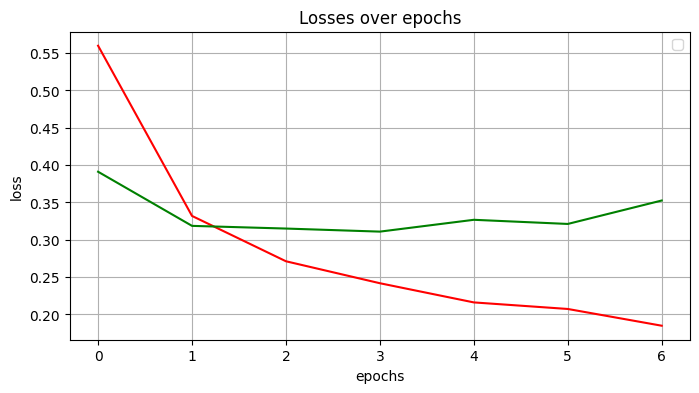

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], color='red')
plt.plot(history.history['val_loss'], color='green')
plt.legend()
plt.grid()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Losses over epochs")
plt.show()

In [26]:
import inspect
print(inspect.getsource(plt.legend))

@_copy_docstring_and_deprecators(Axes.legend)
def legend(*args, **kwargs) -> Legend:
    return gca().legend(*args, **kwargs)



In [33]:
y_pred = model.predict(x_test.astype('str').to_numpy()).flatten()
y_pred = (y_pred >= 0.5).astype('int')
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, target_names=["negative", 'positive']))

              precision    recall  f1-score   support

    negative       0.84      0.90      0.87      4961
    positive       0.89      0.83      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm)